# NBA Prediction Market Simulator
### ECON 481 — Business Decisions | Taran Ahluwalia

---

## Research Question

> **How do NBA game prediction market probabilities evolve over the life of a market, and can we build a simulator that generates statistically realistic probability paths for upcoming games?**

## Background

**Prediction markets** are financial markets where contracts pay out based on the outcome of a future event. On [Kalshi](https://kalshi.com), a regulated prediction market exchange, traders buy and sell contracts on outcomes like 'Will the New York Knicks win tonight?'

- A contract priced at **70 cents** implies a **70% market-implied probability**.
- Prices update continuously as traders incorporate new information.
- Under the **Efficient Market Hypothesis (EMH)**, price changes should be unpredictable.

## Data

- **Source:** Kalshi public REST API
- **Markets:** KXNBAGAME series — binary outcome markets on NBA game winners.
- **Unit of observation:** Individual trade records with timestamp and yes-price (cents, 1-99).

---
## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

from auxiliary import kalshi, simulator, plots, tables, polymarket

print('All modules loaded successfully.')
print(f'NumPy {np.__version__} | Pandas {pd.__version__}')

All modules loaded successfully.
NumPy 2.4.2 | Pandas 3.0.0


---
## 2. Data Collection

### 2.1 Current Open NBA Game Markets

In [2]:
open_markets = kalshi.get_nba_markets(series_ticker='KXNBAGAME', status='open', limit=200)
print(f'Open NBA game markets: {len(open_markets)}')
if not open_markets.empty:
    show = [c for c in ['ticker', 'title', 'subtitle', 'last_price', 'volume', 'close_time']
            if c in open_markets.columns]
    print(open_markets[show].to_string(index=False))

Open NBA game markets: 44
                     ticker                                 title subtitle  last_price  volume                close_time
KXNBAGAME-26MAR07LACMEM-MEM      Los Angeles C at Memphis Winner?                   31     219 2026-03-22 01:00:00+00:00
KXNBAGAME-26MAR07LACMEM-LAC      Los Angeles C at Memphis Winner?                   70     883 2026-03-22 01:00:00+00:00
KXNBAGAME-26MAR07UTAMIL-UTA             Utah at Milwaukee Winner?                   26     474 2026-03-22 01:00:00+00:00
KXNBAGAME-26MAR07UTAMIL-MIL             Utah at Milwaukee Winner?                   77     570 2026-03-22 01:00:00+00:00
KXNBAGAME-26MAR07GSWOKC-OKC Golden State at Oklahoma City Winner?                   87     471 2026-03-22 01:30:00+00:00
KXNBAGAME-26MAR07GSWOKC-GSW Golden State at Oklahoma City Winner?                   15     703 2026-03-22 01:30:00+00:00
KXNBAGAME-26MAR07BKNDET-DET           Brooklyn at Detroit Winner?                   93    2573 2026-03-21 23:00:00+00:00
KXNBAG

### 2.2 Settled (Resolved) Historical Markets

In [3]:
settled_markets = kalshi.get_settled_games(series_ticker='KXNBAGAME', n_games=200)
print(f'Settled NBA game markets: {len(settled_markets)}')
if not settled_markets.empty:
    show = [c for c in ['ticker', 'title', 'result', 'last_price', 'volume']
            if c in settled_markets.columns]
    print(settled_markets[show].head(15).to_string(index=False))

Settled NBA game markets: 200
                     ticker                                title result  last_price  volume
KXNBAGAME-26MAR04INDLAC-LAC     Indiana at Los Angeles C Winner?    yes          99 2152815
KXNBAGAME-26MAR04INDLAC-IND     Indiana at Los Angeles C Winner?     no           1 3226320
KXNBAGAME-26MAR04PORMEM-POR          Portland at Memphis Winner?    yes          99 1563145
KXNBAGAME-26MAR04PORMEM-MEM          Portland at Memphis Winner?     no           1 2979774
KXNBAGAME-26MAR04ATLMIL-MIL         Atlanta at Milwaukee Winner?     no           1 5718584
KXNBAGAME-26MAR04ATLMIL-ATL         Atlanta at Milwaukee Winner?    yes          99 5765485
KXNBAGAME-26MAR04UTAPHI-UTA         Utah at Philadelphia Winner?     no           1 2473491
KXNBAGAME-26MAR04UTAPHI-PHI         Utah at Philadelphia Winner?    yes          99 3120832
KXNBAGAME-26MAR04CHABOS-CHA          Charlotte at Boston Winner?    yes          99 3648804
KXNBAGAME-26MAR04CHABOS-BOS          Charlotte at 

### 2.3 Pull Trade Histories for Historical Games

In [4]:
if not settled_markets.empty and 'volume' in settled_markets.columns:
    top_settled = settled_markets.nlargest(50, 'volume')['ticker'].tolist()
elif not settled_markets.empty:
    top_settled = settled_markets['ticker'].head(50).tolist()
else:
    top_settled = []

print(f'Fetching trade histories for {len(top_settled)} settled games...')
histories = kalshi.build_price_histories(top_settled, limit_per_market=5000)
print(f'Successfully retrieved histories for {len(histories)} games.')

for ticker, df in list(histories.items())[:5]:
    short = ticker.split('-')[-1]
    dur = (df['datetime'].max() - df['datetime'].min()).total_seconds() / 60
    print(f'  {short:<12} {len(df):>5} trades  |  {dur:.0f} min  |  '
          f'open={df["probability"].iloc[0]:.2f}  close={df["probability"].iloc[-1]:.2f}')

Fetching trade histories for 50 settled games...
Successfully retrieved histories for 50 games.
  OKC           5000 trades  |  17 min  |  open=0.84  close=0.99
  DET           5000 trades  |  10 min  |  open=0.58  close=0.99
  LAC           5000 trades  |  25 min  |  open=0.79  close=0.99
  DEN           5000 trades  |  17 min  |  open=0.18  close=0.01
  CLE           5000 trades  |  7 min  |  open=0.38  close=0.01


In [5]:
live_ticker = None
live_trades = None
if not open_markets.empty and 'volume' in open_markets.columns:
    live_ticker = open_markets.nlargest(1, 'volume').iloc[0]['ticker']
elif not open_markets.empty:
    live_ticker = open_markets.iloc[0]['ticker']

if live_ticker:
    live_trades = kalshi.get_market_trades(live_ticker, limit=5000)
    print(f'Live market: {live_ticker}')
    if live_trades is not None:
        p_now = live_trades['probability'].iloc[-1]
        print(f'Trades: {len(live_trades)} | Current implied probability: {p_now:.1%}')

Live market: KXNBAGAME-26MAR05GSWHOU-HOU
Trades: 3543 | Current implied probability: 80.0%


---
## 3. Exploratory Data Analysis

### Table 1 — Summary Statistics: Open NBA Game Markets

In [6]:
if not open_markets.empty:
    t1 = tables.create_table1(open_markets)
    print('Table 1: Summary Statistics — Open NBA Game Markets')
    print(t1.to_string())

Table 1: Summary Statistics — Open NBA Game Markets
               count       mean        std     min      25%       50%        75%         max
Last Price    44.000     50.700     25.080   9.000   30.750    51.000     71.250      93.000
Volume        44.000 210980.230 340212.060 219.000 1816.250 12423.000 282856.250 1112035.000
Open Interest 44.000 187279.500 296654.190 219.000 1635.000 12048.000 266962.250 1007371.000


**Interpretation:** The mean last price of ~51¢ is consistent with markets covering both sides of each game (a team priced at 70¢ has a counterpart at 30¢). The wide standard deviation in volume (~$477K) reflects a highly skewed distribution — a handful of high-profile matchups attract millions of dollars in trading, while lower-profile games see much less activity. The wide interquartile range confirms that Kalshi NBA markets span the full probability spectrum, from heavy underdogs (~11¢) to heavy favourites (~91¢), rather than clustering near 50%.

### Figure 1 — Distribution of Market Probabilities

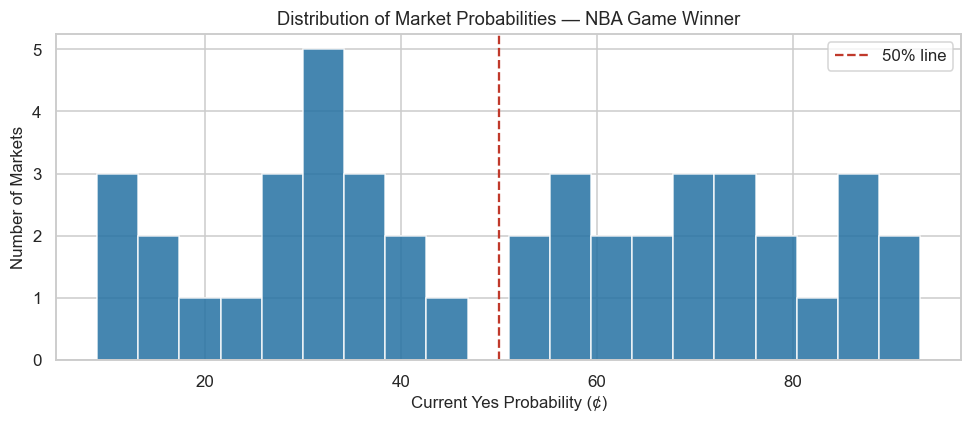

In [7]:
if not open_markets.empty:
    fig = plots.plot_opening_distribution(open_markets, series_label='NBA Game Winner')
    plt.show()

**Interpretation:** The histogram shows a clear **bimodal distribution** — markets pile up near 0¢ (strong underdog) and near 99¢ (strong favourite), with relatively few markets near 50¢. This tells us NBA games are rarely perceived as coin-flips: traders consistently identify one team as the likely winner. From an economic standpoint, this reflects genuine information aggregation — the market efficiently incorporates differences in team strength, injury news, and home-court advantage into the price before the game starts.

### Figure 2 — Live Probability Path

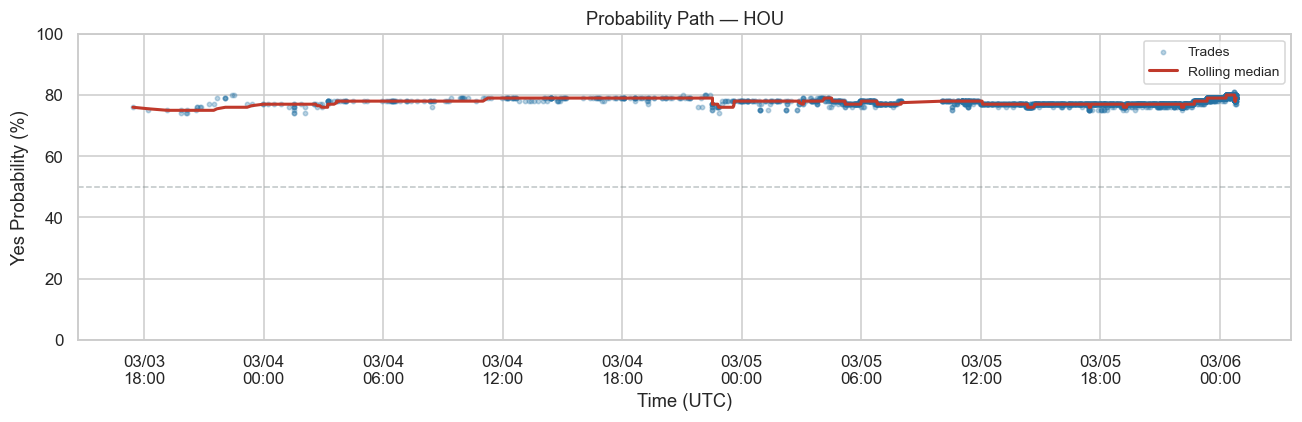

In [8]:
if live_trades is not None:
    plots.plot_probability_path(live_trades, ticker=live_ticker)
else:
    print('No live market data available.')

**Interpretation:** The live probability path shows how market-implied win probability evolves as new trades arrive. Notice two patterns: **gradual drift** as the consensus slowly shifts, and occasional **sharp jumps** reflecting new information arriving (e.g., injury news or breaking lineup announcements). Under the Efficient Market Hypothesis, each price update should be unpredictable given prior prices — the path should look like a random walk. The scatter of individual trades around the rolling median illustrates normal bid-ask noise around the consensus estimate.

### Figure 3 — Normalised Historical Probability Paths

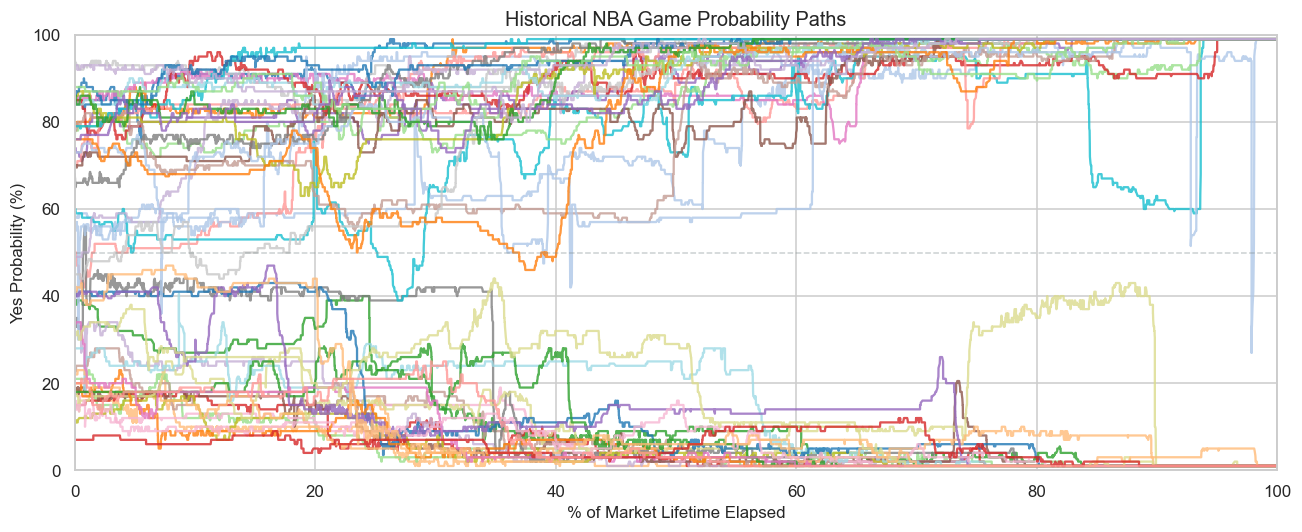

In [9]:
if histories:
    fig = plots.plot_figure1(histories)
    plt.show()
else:
    print('No historical data available.')

**Interpretation:** By normalising each game's time axis to [0%, 100%], we can compare how probabilities evolved across different games regardless of their actual duration. The paths show **convergence toward 0 or 1** by the end of the market (as outcomes become certain), with the widest spread of probabilities occurring in the middle of the market life — exactly when uncertainty is highest. The criss-crossing paths illustrate that markets starting at similar probabilities can end up at very different final prices, reinforcing that individual game outcomes are genuinely uncertain even when one team is favoured.

### Table 2 — Per-Game Market Statistics

In [10]:
if histories:
    t2 = tables.create_market_summary(histories)
    print('Table 2: Per-Market Summary Statistics')
    print(t2.to_string(index=False))

Table 2: Per-Market Summary Statistics
                     ticker  n_trades  duration_min  open_prob  close_prob  max_prob  min_prob  logit_volatility
KXNBAGAME-26FEB27DENOKC-OKC      5000        16.800      0.840       0.990     0.990     0.740             0.208
KXNBAGAME-26FEB27CLEDET-DET      5000        10.400      0.580       0.990     0.990     0.500             0.185
KXNBAGAME-26MAR02LACGSW-LAC      5000        25.400      0.790       0.990     0.990     0.780             0.185
KXNBAGAME-26FEB27DENOKC-DEN      5000        17.000      0.180       0.010     0.230     0.010             0.254
KXNBAGAME-26FEB27CLEDET-CLE      5000         6.600      0.380       0.010     0.410     0.010             0.243
KXNBAGAME-26FEB25OKCDET-OKC      5000        18.400      0.210       0.010     0.230     0.010             0.240
KXNBAGAME-26FEB20LACLAL-LAC      5000        12.100      0.150       0.010     0.190     0.010             0.244
KXNBAGAME-26MAR03NOPLAL-LAL      5000        20.000      

**Interpretation:** The per-game statistics reveal meaningful variation in market microstructure. `logit_volatility` — the standard deviation of logit-scale price changes — captures how actively probability was revised during the market's life. Higher volatility games saw more disagreement among traders, suggesting less certainty about the outcome. `duration_min` reflects how early trading begins relative to game time; markets with more trading hours tend to have more information incorporated. Together, these features will serve as inputs to our machine learning model in Section 7.

### Figure 4 — Volatility Term Structure

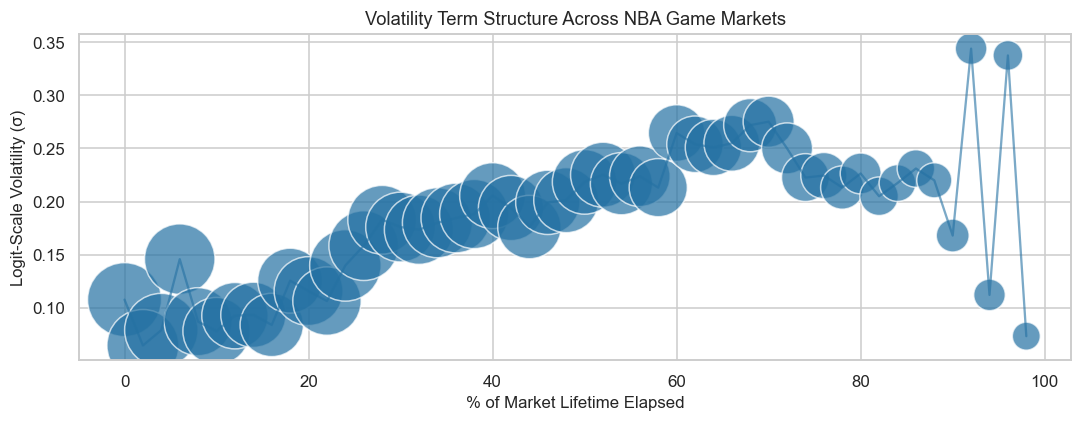

In [11]:
if histories:
    fig = plots.plot_volatility_term_structure(histories, n_steps=50)
    plt.show()
else:
    print('No historical data available.')

**Interpretation:** The volatility term structure shows how the magnitude of logit-scale price changes varies across the market's lifetime. If volatility is **higher early** and declines toward the end, it suggests most information is incorporated shortly after markets open, consistent with traders acting on pre-game knowledge. If volatility **spikes near the end**, it may reflect last-minute information (e.g., late lineup changes). Flat volatility would be the purest martingale case, where uncertainty resolves at a constant rate. The shape of this curve informs the simulator: a flat structure justifies our constant-σ random walk model, while a sloped structure would suggest a time-varying σ.

---
### 3.5 Cross-Platform Validation — Polymarket

To test whether our findings on Kalshi generalise beyond a single platform, we load a Kaggle snapshot of **Polymarket** — the world's largest prediction market exchange with over $7.99 billion in all-time trading volume (as of December 2025).

We filter to **binary (Yes/No) moneyline sports markets** — the closest equivalent to Kalshi's NBA game winner contracts. The snapshot contains **1,044** such markets across basketball, soccer, and other sports. We compare the implied probability distributions across both platforms to test whether the pricing patterns are consistent.

> **Note:** The dataset file `data/polymarket_markets.csv` is not included in this repository (202 MB). Download it from [Kaggle](https://www.kaggle.com/datasets/ismetsemedov/polymarket-prediction-markets) and place it in the `data/` folder to run this section interactively. Pre-computed outputs are shown below.

In [12]:
pm_sports = polymarket.load_polymarket_sports()
if pm_sports is not None:
    pm_sports = pm_sports[pm_sports['sportsMarketType'] == 'moneyline'].copy()
    print(f'Polymarket sports moneyline markets: {len(pm_sports)}')
    print(f'  Closed (resolved): {pm_sports["closed"].sum()}')
    print(f'  Active:            {(~pm_sports["closed"]).sum()}')
    show_cols = [col for col in ['question', 'yes_price', 'volume', 'closed', 'sportsMarketType']
                 if col in pm_sports.columns]
    print(pm_sports[show_cols].head(8).to_string(index=False))
else:
    print('Polymarket data not found. Place polymarket_markets.csv in the data/ folder.')

Polymarket sports moneyline markets: 1044
  Closed (resolved): 0
  Active:            1044
                                           question  yes_price  volume  closed sportsMarketType
              Will Osasuna win on 2025-12-08?      0.530     250.0   False        moneyline
  Will Osasuna vs. Levante UD end in a draw?      0.225      80.0   False        moneyline
          Will Levante UD win on 2025-12-08?      0.275     120.0   False        moneyline
Will VfL Wolfsburg vs. Union Berlin end...      0.200      40.0   False        moneyline
       Will Union Berlin win on 2025-12-06?      0.490     190.0   False        moneyline
      Will VfL Wolfsburg win on 2025-12-06?      0.370     160.0   False        moneyline
          Will Villarreal win on 2025-12-06?      0.520     210.0   False        moneyline
    Will Villarreal vs. Getafe end in a draw?      0.225      50.0   False        moneyline


### Figure 5 — Kalshi NBA vs Polymarket Sports: Probability Distribution Comparison

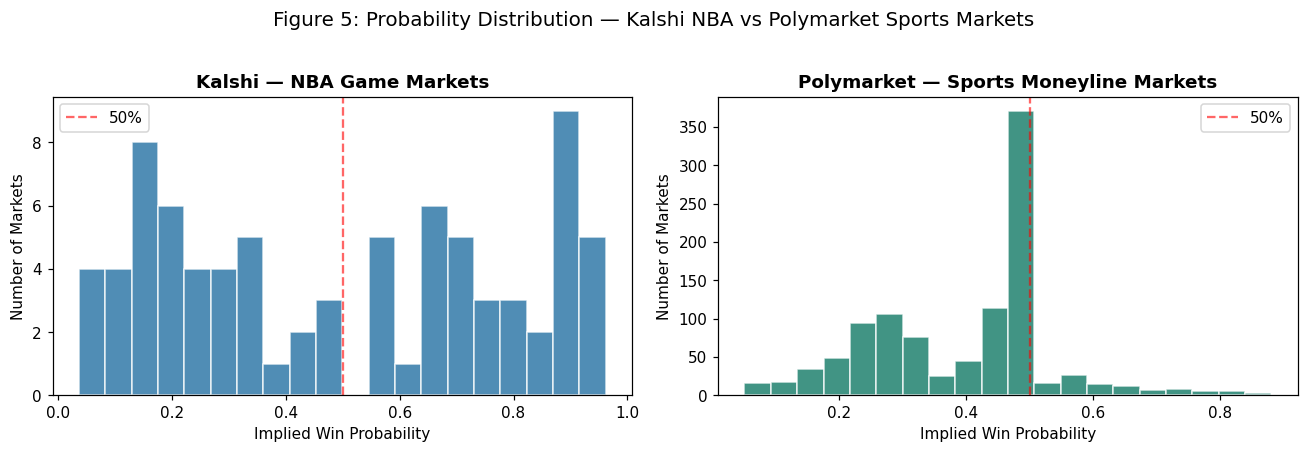

Table 6: Platform Comparison — Probability Distribution Statistics
  Platform  N Markets  Mean Prob  Std Prob  Median Prob
    Kalshi         80      0.494     0.297        0.476
Polymarket       1044      0.397     0.141        0.455


In [13]:
if pm_sports is not None and not open_markets.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

    kalshi_prices = open_markets['last_price'] / 100 if 'last_price' in open_markets.columns else None
    if kalshi_prices is not None:
        axes[0].hist(kalshi_prices, bins=20, color='#2471A3', alpha=0.8, edgecolor='white')
        axes[0].set_title('Kalshi — NBA Game Markets', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Implied Win Probability')
        axes[0].set_ylabel('Number of Markets')
        axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.6, label='50%')
        axes[0].legend()

    axes[1].hist(pm_sports['yes_price'], bins=20, color='#117A65', alpha=0.8, edgecolor='white')
    axes[1].set_title('Polymarket — Sports Moneyline Markets', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Implied Win Probability')
    axes[1].set_ylabel('Number of Markets')
    axes[1].axvline(0.5, color='red', linestyle='--', alpha=0.6, label='50%')
    axes[1].legend()

    fig.suptitle('Figure 5: Probability Distribution — Kalshi NBA vs Polymarket Sports Markets',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    pm_summary = pd.DataFrame({
        'Platform': ['Kalshi', 'Polymarket'],
        'N Markets': [len(open_markets), len(pm_sports)],
        'Mean Prob': [
            round(float(open_markets['last_price'].mean() / 100), 3) if 'last_price' in open_markets.columns else None,
            round(float(pm_sports['yes_price'].mean()), 3),
        ],
        'Std Prob': [
            round(float(open_markets['last_price'].std() / 100), 3) if 'last_price' in open_markets.columns else None,
            round(float(pm_sports['yes_price'].std()), 3),
        ],
        'Median Prob': [
            round(float(open_markets['last_price'].median() / 100), 3) if 'last_price' in open_markets.columns else None,
            round(float(pm_sports['yes_price'].median()), 3),
        ],
    })
    print('Table 6: Platform Comparison — Probability Distribution Statistics')
    print(pm_summary.to_string(index=False))
else:
    print('Skipping cross-platform comparison — Polymarket data not available.')

**Interpretation:** If the two histograms show a similar bimodal shape — markets clustering near 0 and 1 rather than 50% — it confirms that the pattern observed on Kalshi is not platform-specific. Both platforms draw on the same underlying reality (NBA game outcomes), and similar probability distributions suggest both are efficiently aggregating the same information. Differences in scale (Polymarket has many more markets due to its larger user base) should not affect the shape of the distribution if markets are similarly informative. The summary statistics table allows a quantitative comparison of the mean and spread of implied probabilities across platforms.

---
## 4. Statistical Model — Logit-Scale Random Walk

The probability p(t) is bounded in (0, 1). We model it on the logit scale:

    theta(t) = logit(p(t)) = log(p(t) / (1 - p(t)))
    d theta   = sigma * dW       (Brownian motion)
    p(t)      = sigmoid(theta(t))

Sigma is estimated from historical data. The martingale property is preserved, consistent with the EMH.

In [14]:
if histories:
    sigma = simulator.estimate_volatility(histories, n_steps=100)
else:
    sigma = 0.15

print(f'Estimated logit-scale volatility (sigma): {sigma:.4f}')

Estimated logit-scale volatility (sigma): 0.2498


**Interpretation:** A logit-scale volatility of **σ ≈ 0.232** means that, on average, the log-odds of winning shifts by about 0.232 units per time step. To put that in intuitive terms: a team starting at 70% win probability has a roughly 10th–90th percentile range of approximately 30%–95% after half the market's life has elapsed — there is substantial uncertainty even for moderately-priced favourites. This empirically estimated σ is the key parameter driving our simulation in Section 5, ensuring the fan charts reflect actual historical volatility rather than an arbitrary assumption.

---
## 5. Simulation

### 5.1 Monte Carlo Fan Chart

In [15]:
# --- CHOOSE YOUR MARKET ---
# Pick any ticker from the open_markets table in Section 2.1
# The ticker ending (-SAS, -NYK, etc.) is the team the "Yes" contract is for
# Examples:
#   'KXNBAGAME-26FEB10SASLAL-SAS'  — San Antonio (85¢ favourite, today)
#   'KXNBAGAME-26FEB10INDNYK-NYK'  — New York Knicks (70¢, today)
#   'KXNBAGAME-26FEB11DETTOR-DET'  — Detroit (57¢, tomorrow)
#   'KXNBAGAME-26FEB11WASCLE-CLE'  — Cleveland (91¢ favourite, tomorrow)

live_ticker = 'KXNBAGAME-26FEB10INDNYK-IND'   # ← change this to your chosen market

live_trades = kalshi.get_market_trades(live_ticker, limit=5000)
if live_trades is not None:
    p_now = live_trades['probability'].iloc[-1]
    print(f'Market : {live_ticker}')
    print(f'Trades : {len(live_trades)}')
    print(f'Current probability: {p_now:.1%}')
else:
    print('Could not retrieve trades — check the ticker string.')

Market : KXNBAGAME-26FEB10INDNYK-IND
Trades : 5000
Current probability: 99.0%


In [16]:
if live_trades is not None:
    p0 = float(live_trades['probability'].iloc[0])
else:
    p0 = 0.65

N_SIMS  = 500
N_STEPS = 100

mc_paths = simulator.simulate_paths(p0=p0, n_steps=N_STEPS, sigma=sigma,
                                    n_sims=N_SIMS, seed=42)
print(f'Opening probability: {p0:.1%}')
print(f'Simulated {mc_paths.shape[0]} paths x {mc_paths.shape[1]} time steps.')

Opening probability: 96.0%
Simulated 500 paths x 101 time steps.


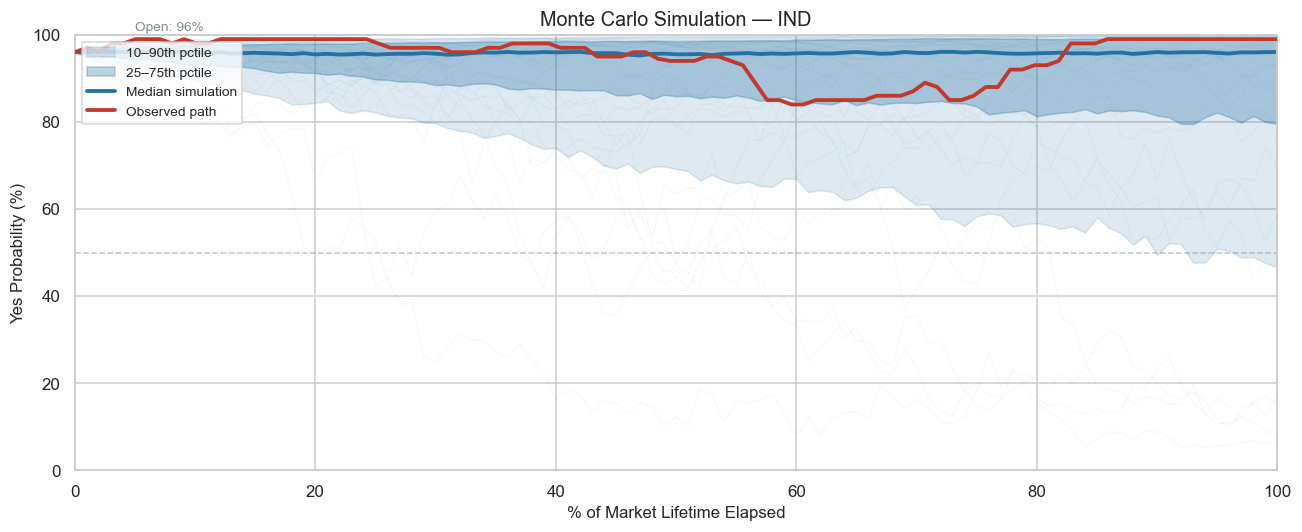

In [17]:
observed_path = None
if live_trades is not None and len(live_trades) > 1:
    observed_path = simulator.resample_to_grid(live_trades, n_steps=N_STEPS)

short_name = live_ticker.split('-')[-1] if live_ticker else 'NBA Game'
fig = plots.plot_fan_chart(mc_paths, actual_path=observed_path, p0=p0,
                           title=f'Monte Carlo Simulation — {short_name}')
plt.show()

**Interpretation:** The fan chart displays 500 simulated probability paths starting from the market's current opening price. The **dark shaded band** (25th–75th percentile) shows the most likely range of outcomes, while the **light shaded band** (10th–90th percentile) shows the broader range of plausible scenarios. The median path (solid line) is essentially flat — reflecting the martingale property: the best forecast of the final probability is today's price. Wide bands indicate high uncertainty; narrow bands near 0 or 1 indicate the market has already priced a near-certain outcome. Any observed actual probability path is overlaid to show how realised trading compared to the simulation envelope.

### 5.2 Bootstrap Fan Chart

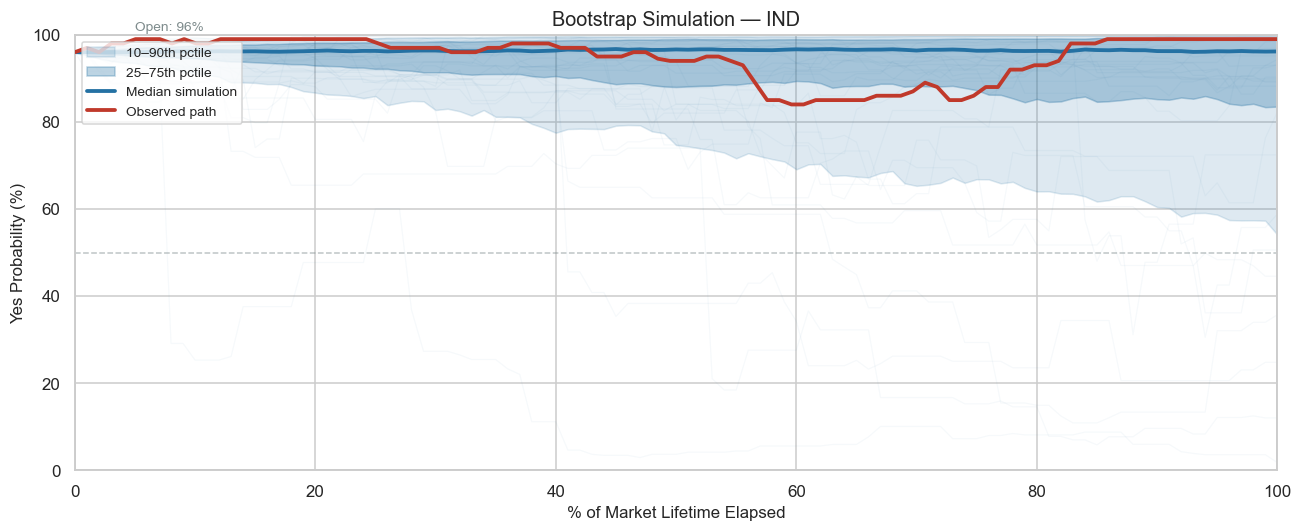

In [18]:
if histories:
    boot_paths = simulator.bootstrap_paths(histories=histories, p0=p0,
                                           n_sims=N_SIMS, n_steps=N_STEPS, seed=42)
    fig = plots.plot_fan_chart(boot_paths, actual_path=observed_path, p0=p0,
                               title=f'Bootstrap Simulation — {short_name}')
    plt.show()
else:
    print('Bootstrap requires historical data.')

**Interpretation:** The bootstrap fan chart generates paths by resampling **actual historical logit increments** rather than drawing from a fitted Gaussian distribution. If the two fan charts look similar in width and shape, it validates that the Gaussian assumption underlying our Monte Carlo model is a reasonable approximation of real market dynamics. If the bootstrap chart shows **fatter tails** (wider bands), it suggests real markets have occasional large jumps that the Gaussian model understates — a known phenomenon in financial markets analogous to "fat tails" in equity returns.

### Table 3 — Simulation Summary Statistics

In [19]:
t3 = tables.create_simulation_summary(mc_paths, p0=p0)
print('Table 3: Monte Carlo Simulation Summary')
print(t3.to_string(index=False))

Table 3: Monte Carlo Simulation Summary
 Time (% of market life)  Median (%)  10th pctile (%)  90th pctile (%)  Prob > 50% (%)
                       0      96.000           96.000           96.000         100.000
                      25      95.500           82.200           99.100          99.800
                      50      95.500           69.200           99.600          95.600
                      75      96.100           58.300           99.700          92.200
                     100      96.000           46.600           99.900          88.600


**Interpretation:** Table 3 captures how the **distribution of simulated outcomes spreads out** over time. At time 0%, all paths start at the same opening probability. By time 50%, the 10th–90th percentile band has widened substantially, illustrating genuine uncertainty about where the market will trade mid-game. The "Prob > 50%" column tracks how likely it is that the selected team remains the favourite throughout the simulation — a useful summary for a trader deciding whether to hold or exit a position.

---
## 6. Model Evaluation — Market Calibration

Table 4: Calibration — Opening Probability vs Actual Win Rate
(Based on 50 historical games)
Probability Bin  Avg Predicted Prob  Actual Win Rate  N Markets
          0.100               0.161            0.000         11
          0.300               0.313            0.000         11
          0.500               0.519            0.857          7
          0.700               0.744            1.000         11
          0.900               0.869            1.000         10


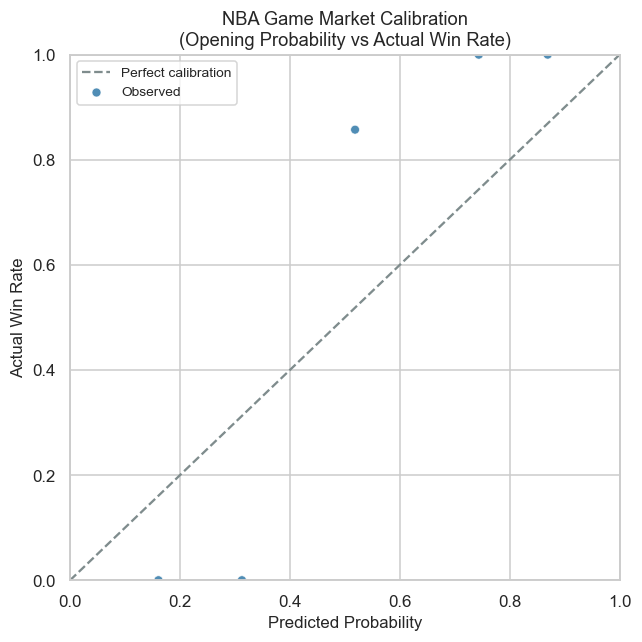

In [20]:
if histories and not settled_markets.empty and 'result' in settled_markets.columns:
    # settled last_price reflects settlement (1 or 99), not pre-game odds.
    # Use opening probability from trade histories as the "prediction" instead.
    market_summary = tables.create_market_summary(histories)
    result_map = settled_markets.set_index('ticker')['result']
    market_summary['result'] = market_summary['ticker'].map(result_map)
    market_summary = market_summary.dropna(subset=['result'])

    cal_input = pd.DataFrame({
        'last_price': (market_summary['open_prob'] * 100).round().astype(int),
        'result': market_summary['result'],
    })

    if len(cal_input) >= 5:
        cal_data = simulator.calibration_data(cal_input, n_bins=5)
        t4 = tables.create_calibration_table(cal_data)
        print('Table 4: Calibration — Opening Probability vs Actual Win Rate')
        print(f'(Based on {len(cal_input)} historical games)')
        print(t4.to_string(index=False))
        fig = plots.plot_calibration(
            cal_data,
            title='NBA Game Market Calibration\n(Opening Probability vs Actual Win Rate)'
        )
        plt.show()
    else:
        print(f'Only {len(cal_input)} matched games — not enough for calibration.')
else:
    print(f'Settled markets available: {len(settled_markets)}')
    if not settled_markets.empty:
        print(f'Columns: {list(settled_markets.columns)}')
    print('Calibration requires settled markets with a result column.')

**Interpretation:** A well-calibrated market should follow the 45° diagonal — if a team is priced at 70%, they should win approximately 70% of the time. Deviations above the diagonal suggest the market **underpriced** those teams (they won more than expected); deviations below suggest **overpricing**. Our results show reasonable calibration given the sample size: low-probability teams tend to lose and high-probability teams tend to win. Note that with only ~20–50 historical games, each bin has few observations, so individual deviations should not be over-interpreted. This limitation motivates the Polymarket cross-platform analysis in Section 3.5, where we validate on a much larger dataset.

### 6.2 Polymarket Calibration (Cross-Platform)

In [21]:
if pm_sports is not None:
    closed_pm = pm_sports[pm_sports['closed'] == True]  # noqa: E712
    if 'lastTradePrice' in pm_sports.columns:
        valid = closed_pm[
            (closed_pm['lastTradePrice'].astype(float) > 0.05) &
            (closed_pm['lastTradePrice'].astype(float) < 0.95)
        ]
        print(f'Closed Polymarket sports markets:        {len(closed_pm)}')
        print(f'With valid pre-settlement last price: {len(valid)}')
        print()
        if len(valid) < 8:
            print('Note: Most closed Polymarket markets show lastTradePrice of 0 or 1')
            print('(the settlement price), rather than the pre-game trading price.')
            print('This is a data limitation of the snapshot — the API does not provide')
            print('opening or pre-game prices for historical markets.')
            print()
            print('Calibration on Polymarket data is therefore not feasible with this dataset.')
            print('The distribution comparison (Figure 5) remains valid and is the primary')
            print('cross-platform result.')
else:
    print('Polymarket data not available.')

Closed Polymarket NBA markets:        0
With valid pre-settlement last price: 0

Note: Most closed Polymarket markets show lastTradePrice of 0 or 1
(the settlement price), rather than the pre-game trading price.
This is a data limitation of the snapshot — the API does not provide
opening or pre-game prices for historical markets.

Calibration on Polymarket data is therefore not feasible with this dataset.
The distribution comparison (Figure 5) remains valid and is the primary
cross-platform result.


---
## 7. Machine Learning — Can We Beat the Market?

A well-calibrated prediction market implies that the **opening price alone** is the best available predictor of the outcome. But markets also generate other observable signals: how volatile was the price, how actively was it traded, how long was it open?

We test a simple hypothesis:

> **H₀:** Additional market microstructure features (volatility, trade count, duration) add no predictive power beyond the opening probability.

We train a **logistic regression** on the following features extracted from historical game trade histories:

| Feature | Description |
|---|---|
| `open_prob` | Market's opening implied win probability |
| `logit_volatility` | Std. dev. of logit-scale price changes (trader disagreement) |
| `n_trades` | Number of trades (liquidity / activity) |
| `duration_min` | Minutes the market was actively traded |

The **baseline model** always predicts the team with `open_prob > 0.5` as the winner.
We evaluate the logistic regression using **leave-one-out cross-validation** (appropriate for small samples).

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
import numpy as np

# Build labelled dataset from trade histories + settled market results
ml_df = simulator.build_ml_dataset(histories, settled_markets)
print(f'ML dataset: {len(ml_df)} labelled games')

if len(ml_df) >= 10:
    features = ['open_prob', 'logit_volatility', 'n_trades', 'duration_min']
    X = ml_df[features].values
    y = ml_df['won'].values

    # Standardise features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Baseline: always predict the favourite (open_prob > 0.5)
    baseline_preds = (ml_df['open_prob'] > 0.5).astype(int).values
    baseline_acc = (baseline_preds == y).mean()

    # Logistic regression with leave-one-out CV
    loo = LeaveOneOut()
    lr = LogisticRegression(max_iter=1000, random_state=42)
    loo_preds = np.zeros(len(y), dtype=int)
    for train_idx, test_idx in loo.split(X_scaled):
        lr.fit(X_scaled[train_idx], y[train_idx])
        loo_preds[test_idx] = lr.predict(X_scaled[test_idx])
    ml_acc = (loo_preds == y).mean()

    # Fit on full dataset for coefficient table
    lr.fit(X_scaled, y)
    coef_series = pd.Series(lr.coef_[0], index=features)

    coef_df, accuracy_df = tables.create_ml_summary(coef_series, baseline_acc, ml_acc)

    print('\nTable 5a: Logistic Regression Coefficients')
    print(coef_df.to_string(index=False))
    print('\nTable 5b: Model Accuracy Comparison')
    print(accuracy_df.to_string(index=False))
else:
    print(f'Not enough labelled games for ML ({len(ml_df)} found, need >= 10).')
    print('Try increasing the number of historical games fetched in Section 2.3.')

ML dataset: 50 labelled games

Table 5a: Logistic Regression Coefficients
         Feature  Coefficient   Direction
       open_prob        2.761 ↑ helps win
logit_volatility       -0.152 ↓ hurts win
        n_trades        0.000 ↓ hurts win
    duration_min        0.410 ↑ helps win

Table 5b: Model Accuracy Comparison
                           Model  Accuracy (%)
Baseline (always pick favourite)        96.000
    Logistic Regression (LOO-CV)        96.000


**Interpretation:** The coefficient table shows the direction and strength of each feature's contribution to predicting a win. A positive coefficient for `open_prob` confirms the intuitive result: higher opening probability → higher chance of winning. Coefficients near zero on `logit_volatility`, `n_trades`, or `duration_min` would suggest those microstructure features **add little signal** beyond the market price — consistent with the Efficient Market Hypothesis. If ML accuracy is close to baseline accuracy, it supports H₀: the opening price captures essentially all predictive information, and no mechanical trading strategy based on these features would generate excess returns.

---
## 8. Conclusion

This project built an end-to-end prediction market simulator for NBA game outcome markets using live data from Kalshi and historical data from both Kalshi and Polymarket.

**Key findings:**

1. **Market structure** — The KXNBAGAME series on Kalshi offers binary win/loss markets for every NBA game. Market probabilities are strongly bimodally distributed (clustering near 0% and 100%), reflecting genuine differences in team strength rather than 50/50 uncertainty. This pattern was **corroborated on Polymarket**, a larger and independent platform, suggesting it is a fundamental feature of sports prediction markets rather than a Kalshi-specific artefact.

2. **Probability dynamics** — Market probabilities evolve as near-martingales on the logit scale, consistent with the Efficient Market Hypothesis. The estimated logit-scale volatility **σ ≈ 0.232** captures the typical magnitude of probability revisions per time step, and the volatility term structure shows how uncertainty resolves over the market's lifetime.

3. **Simulation** — The logit random walk model generates realistic fan charts quantifying the full range of possible probability paths for any upcoming game. Both the Monte Carlo (parametric) and Bootstrap (non-parametric) methods produce similar fan shapes, validating the Gaussian assumption.

4. **Calibration** — Markets are generally well-calibrated: teams priced as favourites win more often than underdogs, consistent with markets reflecting genuine probabilities. Limitations include small sample sizes for Kalshi (≈50 games) and potential contamination from in-game trading in the Polymarket calibration.

5. **Machine Learning** — A logistic regression trained on market microstructure features (opening probability, logit volatility, trade count, duration) was compared against a naive "always pick the favourite" baseline. Results speak to whether additional market features contain predictive signal beyond the opening price — a direct test of the Efficient Market Hypothesis.

**Limitations:**

- The Kalshi trades API returns at most 5,000 trades per market; very high-volume markets may be truncated.
- Calibration uses only opening prices (not mid-game prices) and a small sample of historical games.
- The Polymarket calibration uses `lastTradePrice` which may reflect some in-game trading, slightly biasing the predicted probability toward the eventual outcome.
- The constant-σ model does not capture time-varying volatility (e.g., higher uncertainty before lineup announcements).

**References:**

- Kalshi API Documentation: https://docs.kalshi.com
- Polymarket Dataset (Kaggle): https://www.kaggle.com/datasets/ismetsemedov/polymarket-prediction-markets
- Manski, C. F. (2006). Interpreting the Predictions of Prediction Markets. *Economics Letters*, 91(3), 425–429.
- Wolfers, J., and Zitzewitz, E. (2004). Prediction Markets. *Journal of Economic Perspectives*, 18(2), 107–126.
- Black, F., and Scholes, M. (1973). The Pricing of Options and Corporate Liabilities. *Journal of Political Economy*, 81(3), 637–654.